<a href="https://colab.research.google.com/github/harishmuh/Deep-Learning_study/blob/main/DNN_CIFAR10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# **Deep Neural Network (DNN) - Image classification - CIFAR10 dataset**

---

![image](https://corochann.com/wp-content/uploads/2021/09/cifar10_plot_more-700x700-1.png)

### **Context**

In this tutorial, we will build neural network with deep neural network (DNN) to classify image of objects from Canadian Institute for Advance Research (CIFAR-10) dataset.



### **About CIFAR-10 dataset**

CIFAR-10 contains:

* 60,000 color images

* 32 × 32 pixels

* 3 color channels (RGB)

* 10 object classes (airplane, car, bird, cat, deer, dog, frog, horse, ship, truck)

## **Initial setup**

In [16]:
# Importing libraries
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, BatchNormalization
import matplotlib.pyplot as plt
import numpy as np

# Warning
import warnings
warnings.filterwarnings('ignore')

# style
plt.style.use('ggplot')

**Loading dataset**

In [2]:
# Loading dataset of CIFAR-10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


**Checking data shape**

In [3]:
# Train data
X_train.shape

(50000, 32, 32, 3)

In [4]:
# Test data
X_test.shape

(10000, 32, 32, 3)

So, 50000 data will be used as training images and 10000 data will be used as testing images. The image width will be 32 x 32 (pixels). The last score of 3 represents the RGB color.

**Verifying the data**

To verify that the dataset looks correct, let's plot the first 25 images from the training set and display the class name below each image:

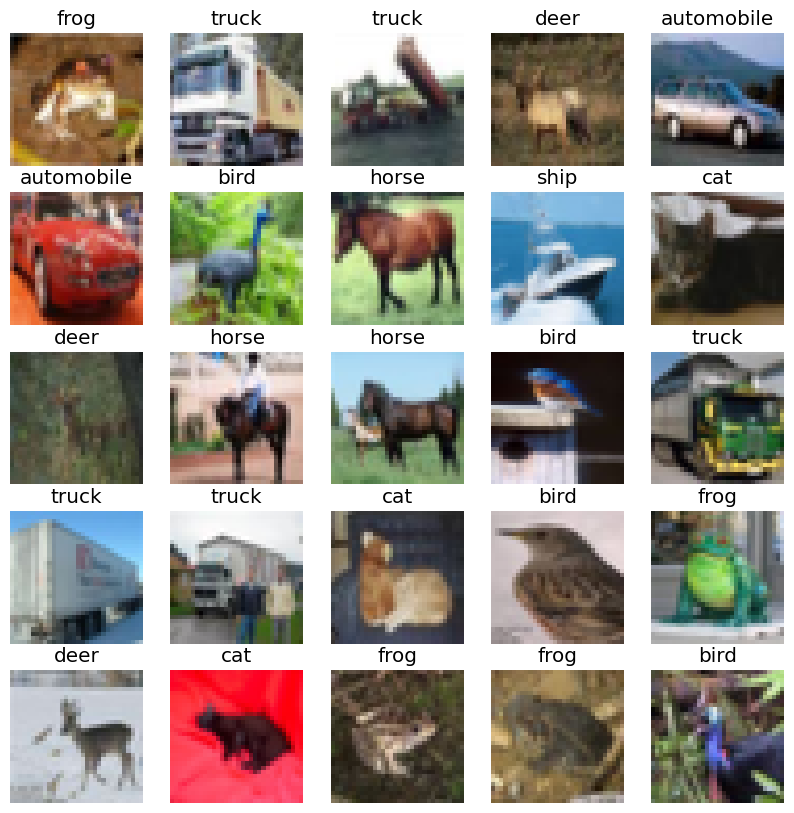

In [5]:
# Verifying the data
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']


# Displaying six images
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    # The CIFAR labels happen to be arrays, # we need the extra index
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.show()

## **Data preprocessing**

We conduct data normalisation to improve model convergency process

In [6]:
# Data normalisation

# Normalize pixel values to be between 0 and 1
X_train = X_train/255.0
X_test = X_test/255.0

To train DNN model better and faster, we need two callback functions `EarlyStopping()` and `ModelCheckpoint()`. Both callback functions will stop the training after optimum performance is being achieved.

The optimum model will be saved in `best_model.keras`

In [7]:
# Calling callback functions

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# If the error value does not change after 5 iterations, stop the training process
es_cb = EarlyStopping(monitor='val_loss', patience=5)

# Saving best model in this filepath
md_cb = ModelCheckpoint(filepath='best_model.keras', save_best_only=True)

## **Model Building**

In [8]:
# DNN building

tf.random.set_seed(32)

# Setting Sequential DNN model
model = Sequential()

# Setting input layer after image flattening
model.add(Flatten(input_shape=(32,32,3)))

# Hidden layer: 512 neurons & relu activation function
model.add(Dense(512, activation='relu'))
model.add(BatchNormalization())

# Hidden layer: 256 neurons & relu activation function
model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())

# Hidden layer: 128 neurons & relu activation function
model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())

# Setting output layer: 10 neurons & softmax activation function
model.add(Dense(10, activation='softmax'))

## **Model compilation**

In [10]:
# Compiling model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Summarizing model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,742,474 (6.65 MB)

 Trainable params: 1,740,682 (6.64 MB)

 Non-trainable params: 1,792 (7.00 KB)

We have 1,742,474 parameters

## **Model training**

In [11]:
# Model training
# Model will be training with 10 epoch (number of iteration of all dataset)

historyDNN = model.fit(X_train,
                       y_train,
                       epochs=100,
                       validation_split=0.2,
                       batch_size=64,
                       callbacks=[es_cb, md_cb])

Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.3874 - loss: 1.7270 - val_accuracy: 0.3468 - val_loss: 1.9092
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.4534 - loss: 1.5316 - val_accuracy: 0.3839 - val_loss: 1.7040
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.4836 - loss: 1.4462 - val_accuracy: 0.3780 - val_loss: 1.7639
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.5075 - loss: 1.3812 - val_accuracy: 0.3678 - val_loss: 1.8092
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.5268 - loss: 1.3263 - val_accuracy: 0.4097 - val_loss: 1.7187
Epoch 6/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.5454 - loss: 1.2764 - val_accuracy: 0.4138 - val_loss: 1.7313
Epoch 7/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.5691 - loss: 1.2121 - val_accuracy: 0.4162 - val_loss: 1.8056


## **Model evaluation**

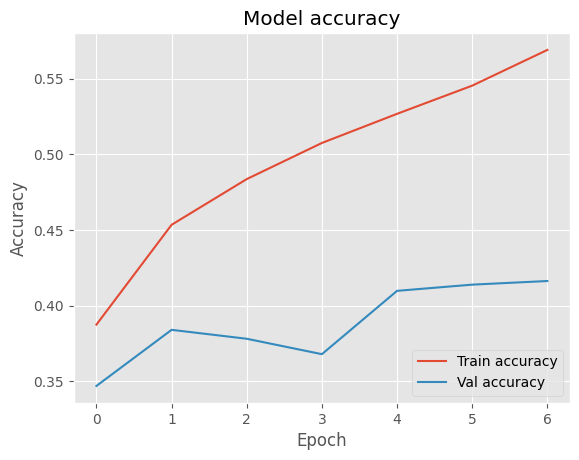

In [12]:
# Plotting accuracy
plt.plot(historyDNN.history['accuracy'])
plt.plot(historyDNN.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train accuracy', 'Val accuracy'], loc='lower right')
plt.show()

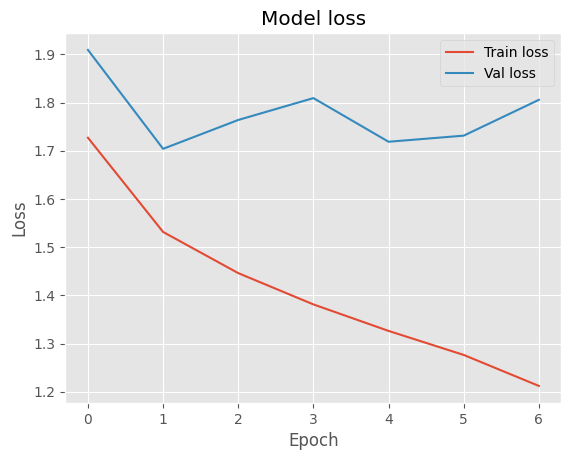

In [13]:
# Plotting loss
plt.plot(historyDNN.history['loss'])
plt.plot(historyDNN.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train loss', 'Val loss'], loc='upper right')
plt.show()

In [15]:
# Model evaluation
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f'Test Accuracy: {test_acc:.4f}')

313/313 - 1s - 5ms/step - accuracy: 0.4098 - loss: 1.7774
Test Accuracy: 0.4098


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


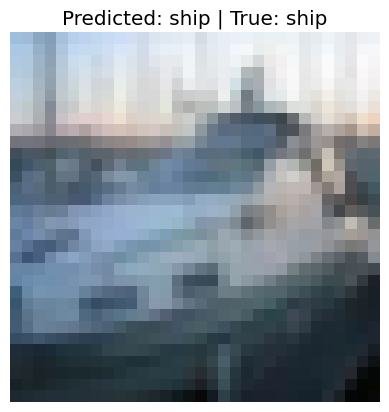

In [19]:
# Prediction and display result
predictions = model.predict(X_test)

sample_index = 2
predicted_class = np.argmax(predictions[sample_index])
true_class = y_test[sample_index][0]

plt.imshow(X_test[sample_index])
plt.title(f"Predicted: {class_names[predicted_class]} | True: {class_names[true_class]}")
plt.axis("off")
plt.show()

## **Conclusion**

We have about 40% accuracy. We need to improve the model to further increase performance.